# Загрузка и тестирование модели

Ноутбук для загрузки модели с готовыми весами, функциями для тестирования на исходной выборке и сво

## Тестирование изображения

In [31]:
import torch
import torch.nn as nn
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import cv2
import os

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Используется устройство: {device}")

def get_model(num_classes=3):
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(num_classes=3)

model_paths = [
    '../models/best_model.pth',
    'models/best_model.pth',
    'D:/satellite_vision_project/models/best_model.pth'
]

model_loaded = False
for path in model_paths:
    if os.path.exists(path):
        print(f"Загрузка модели из: {path}")
        model.load_state_dict(torch.load(path, map_location=device))
        model_loaded = True
        break

if not model_loaded:
    print("Модель не найдена!")
else:
    model = model.to(device)
    model.eval()
    print("Модель успешно загружена!")

class_names = {1: 'building', 2: 'tank'}
colors = {1: 'blue', 2: 'red'}

def load_and_preprocess_image(image_path, target_size=(640, 640)):
    """Загружает и подготавливает изображение для модели"""
    image = Image.open(image_path).convert('RGB')
    original_size = image.size
    
    target_w, target_h = target_size
    orig_w, orig_h = image.size
    
    scale = min(target_w / orig_w, target_h / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    
    image_resized = image.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    padded_image = Image.new('RGB', target_size, (0, 0, 0))
    offset_x = (target_w - new_w) // 2
    offset_y = (target_h - new_h) // 2
    padded_image.paste(image_resized, (offset_x, offset_y))
    
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    image_tensor = transform(padded_image)
    
    metadata = {
        'original_size': original_size,
        'scale': scale,
        'offset': (offset_x, offset_y)
    }
    
    return image_tensor, metadata

def predict_image(model, image_path, device, confidence_threshold=0.5):
    """Предсказание на одном изображении"""
    image_tensor, metadata = load_and_preprocess_image(image_path)
    
    model.eval()
    with torch.no_grad():
        image_batch = image_tensor.unsqueeze(0).to(device)
        predictions = model(image_batch)
        pred_dict = predictions[0]
        
        mask = pred_dict['scores'] >= confidence_threshold
        
        if mask.sum() > 0:
            boxes = pred_dict['boxes'][mask].cpu().numpy()
            labels = pred_dict['labels'][mask].cpu().numpy()
            scores = pred_dict['scores'][mask].cpu().numpy()

            boxes_original = []
            for box in boxes:
                x_min, y_min, x_max, y_max = box
                
                offset_x, offset_y = metadata['offset']
                x_min -= offset_x
                y_min -= offset_y
                x_max -= offset_x
                y_max -= offset_y
                
                scale = metadata['scale']
                x_min /= scale
                y_min /= scale
                x_max /= scale
                y_max /= scale
                
                x_min = max(0, min(x_min, metadata['original_size'][0]))
                y_min = max(0, min(y_min, metadata['original_size'][1]))
                x_max = max(0, min(x_max, metadata['original_size'][0]))
                y_max = max(0, min(y_max, metadata['original_size'][1]))
                
                boxes_original.append([x_min, y_min, x_max, y_max])
            
            return {
                'boxes': np.array(boxes_original),
                'labels': labels,
                'scores': scores,
                'image': Image.open(image_path).convert('RGB')
            }
    return None

def visualize_prediction(result, confidence_threshold=0.5):
    """Визуализирует результат предсказания"""
    if result is None:
        print("Объектов не обнаружено")
        return
    
    image = result['image']
    boxes = result['boxes']
    labels = result['labels']
    scores = result['scores']
    
    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(image)
    
    for box, label, score in zip(boxes, labels, scores):
        if score >= confidence_threshold:
            x_min, y_min, x_max, y_max = box
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=2, edgecolor=colors[label], facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, f"{class_names[label]}: {score:.2f}", 
                    fontsize=10, color=colors[label], weight='bold')
    
    ax.set_title(f"Результаты детекции")
    plt.tight_layout()
    plt.show()

Используется устройство: cuda
Загрузка модели из: ../models/best_model.pth
Модель успешно загружена!


In [32]:
def predict_with_full_adaptation(model, image_path, device):
    """
    Полная адаптация: перебор масштабов + цветокоррекция
    """
    original = Image.open(image_path).convert('RGB')
    orig_w, orig_h = original.size

    def enhance_image(img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced)

    enhanced = enhance_image(original)
    scales = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
    
    best_result = None
    best_count = 0
    
    for scale in scales:
        new_w = int(orig_w * scale)
        new_h = int(orig_h * scale)
        
        if new_w > 2000 or new_h > 2000:
            continue
            
        resized = enhanced.resize((new_w, new_h), Image.Resampling.LANCZOS)
        temp_path = "../data/temp_adapted.jpg"
        resized.save(temp_path)
        
        result = predict_image(model, temp_path, device, confidence_threshold=0.25)
        
        if result and len(result['boxes']) > best_count:
            best_count = len(result['boxes'])
            best_result = result
            best_result['scale'] = scale
        
        if os.path.exists(temp_path):
            os.remove(temp_path)
    
    return best_result

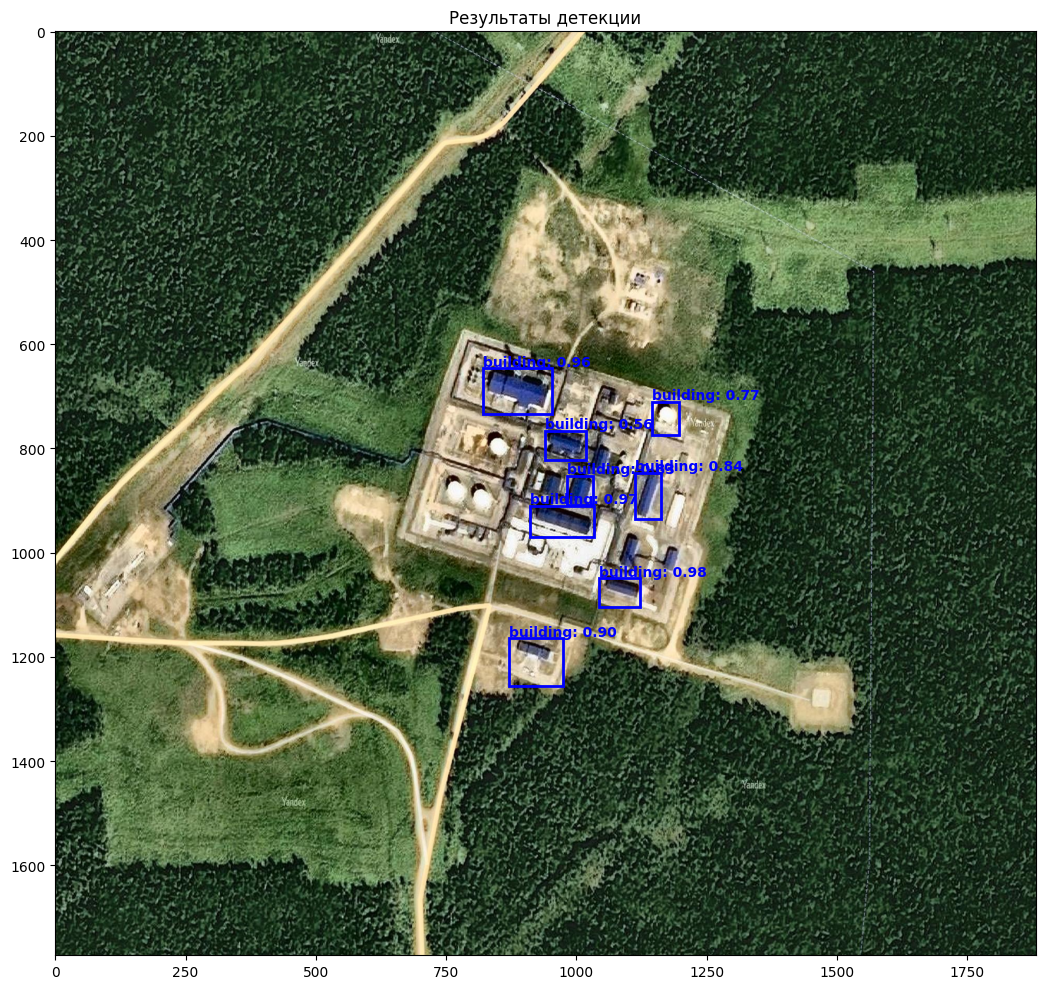

In [33]:
my_image = "../data/my_images/img4.png"
result = predict_with_full_adaptation(model, my_image, device)

if result:
    visualize_prediction(result)
else:
    print("Объекты не найдены. Возможно, на изображении действительно нет зданий/резервуаров.")